# Alignment sanity check v2: SIFT/ORB + homography, `data/processed/aligned_raw/`

**Why this changed:** a manual visual review of `India_071`'s output from the *previous* (OpenCV `matchTemplate`) alignment approach found the mask floating on the sclera (white of the eye) instead of the lower eyelid -- a complete, spatially-wrong alignment, despite a high (0.995) appearance-correlation confidence score. `matchTemplate` has no geometric constraint, so it can lock onto a *different* region that happens to correlate well; a high score never guaranteed a *correct* location, and the "check the mask isn't blank" sanity check from the first version could not catch this failure mode at all (the mask was very much non-blank, just in the wrong place).

**New method** (`scripts/build_aligned_dataset.py`): SIFT (CLAHE-contrast-enhanced, since conjunctiva tissue is naturally low-contrast and starves SIFT of keypoints otherwise), with ORB as a fallback, matched via Lowe's-ratio-filtered BFMatcher, then `cv2.findHomography(..., cv2.RANSAC)` to estimate a full homography from the surviving correspondences -- geometrically constrained (many independent keypoints must agree on one consistent transform), rather than a single global appearance-correlation score.

**Result of the full 217-patient run:** 202/217 aligned (15 honest failures -- rejected via geometric sanity checks rather than silently producing a wrong result); all 202 via SIFT; inlier counts range 5-2014 (9 flagged low-confidence, <15 inliers).

This notebook's 10-patient sample **always includes `India_071`** (the patient that exposed the original failure), plus 9 more random patients. For each, it shows:
1. The full raw eye photo actually used for training (`data/processed/aligned_raw/images/{patient_id}.jpg`).
2. The *original* palpebral crop (`data/processed/masks/{patient_id}_palpebral.png`) -- a reference for what tissue region the mask is supposed to capture.
3. The new aligned mask, overlaid (semi-transparent red) on the same raw photo it's paired with for training -- with positive-pixel count, matching method, and RANSAC inlier count in the title.

**This data has not been declared correct** -- these visual checks are exactly what's needed to decide that, and no training should happen until they're reviewed.

A bonus final section scans **all** patients (not just the 10 sampled) for blank/near-blank masks and lists every patient whose alignment failed outright.

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

# Assumes the notebook is run from within notebooks/ (Jupyter's default cwd
# when opened from that folder). If running elsewhere (e.g. adapted for
# Kaggle), just set PROJECT_ROOT directly instead.
PROJECT_ROOT = Path("..").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

ALIGNED_ROOT = PROCESSED_DIR / "aligned_raw"
ALIGNED_IMAGES_DIR = ALIGNED_ROOT / "images"
ALIGNED_MASKS_DIR = ALIGNED_ROOT / "masks"
ALIGNMENT_LOG_CSV = ALIGNED_ROOT / "alignment_log.csv"
ORIGINAL_CROPS_DIR = PROCESSED_DIR / "masks"  # Phase 0's original palpebral crop PNGs
SPLITS_CSV = PROCESSED_DIR / "dataset_splits.csv"

print("PROJECT_ROOT:        ", PROJECT_ROOT)
print("ALIGNED_IMAGES_DIR exists:", ALIGNED_IMAGES_DIR.exists())
print("ALIGNED_MASKS_DIR exists: ", ALIGNED_MASKS_DIR.exists())
print("ALIGNMENT_LOG_CSV exists: ", ALIGNMENT_LOG_CSV.exists())
print("ORIGINAL_CROPS_DIR exists:", ORIGINAL_CROPS_DIR.exists())
print("SPLITS_CSV exists:        ", SPLITS_CSV.exists())

alignment_log = pd.read_csv(ALIGNMENT_LOG_CSV).set_index("patient_id")
print(f"\nAlignment log: {len(alignment_log)} patients, "
      f"{(alignment_log['status'] == 'ok').sum()} ok, "
      f"{(alignment_log['status'] != 'ok').sum()} failed")

PROJECT_ROOT:         D:\khaje\EYES-DEFY-ANEMIA
ALIGNED_IMAGES_DIR exists: True
ALIGNED_MASKS_DIR exists:  True
ALIGNMENT_LOG_CSV exists:  True
ORIGINAL_CROPS_DIR exists: True
SPLITS_CSV exists:         True

Alignment log: 217 patients, 202 ok, 15 failed


In [2]:
RANDOM_SEED = 42  # change (or remove the seed() call) for a different random sample each run
MUST_INCLUDE = ["India_071"]  # the patient that exposed the original matchTemplate failure

random.seed(RANDOM_SEED)

splits_df = pd.read_csv(SPLITS_CSV)
all_patient_ids = splits_df["patient_id"].tolist()

remaining_pool = [p for p in all_patient_ids if p not in MUST_INCLUDE]
sample_patient_ids = MUST_INCLUDE + random.sample(remaining_pool, 9)
print("Sampled patients (India_071 guaranteed first):", sample_patient_ids)

Sampled patients (India_071 guaranteed first): ['India_071', 'Italy_070', 'India_029', 'India_007', 'Italy_097', 'India_072', 'India_063', 'India_058', 'India_036', 'Italy_096']


## Per-patient visual check (10 random patients)

Each row below is one patient: raw photo | original crop (reference) | aligned mask overlay. The overlay's title states the positive-pixel count explicitly -- if it says 0, the mask for that patient is completely blank.

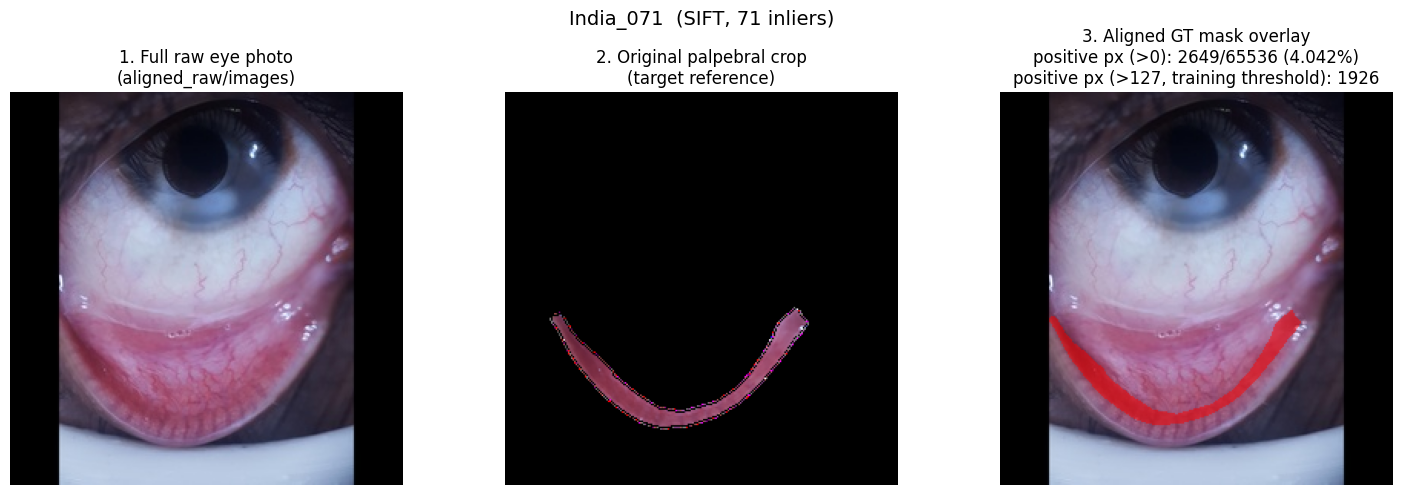

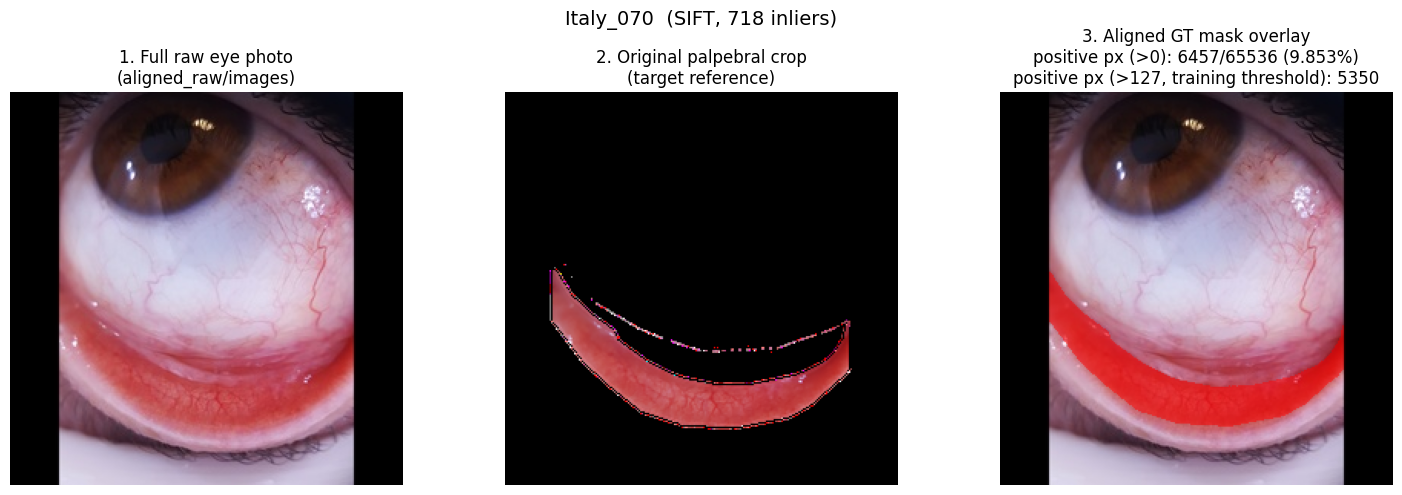

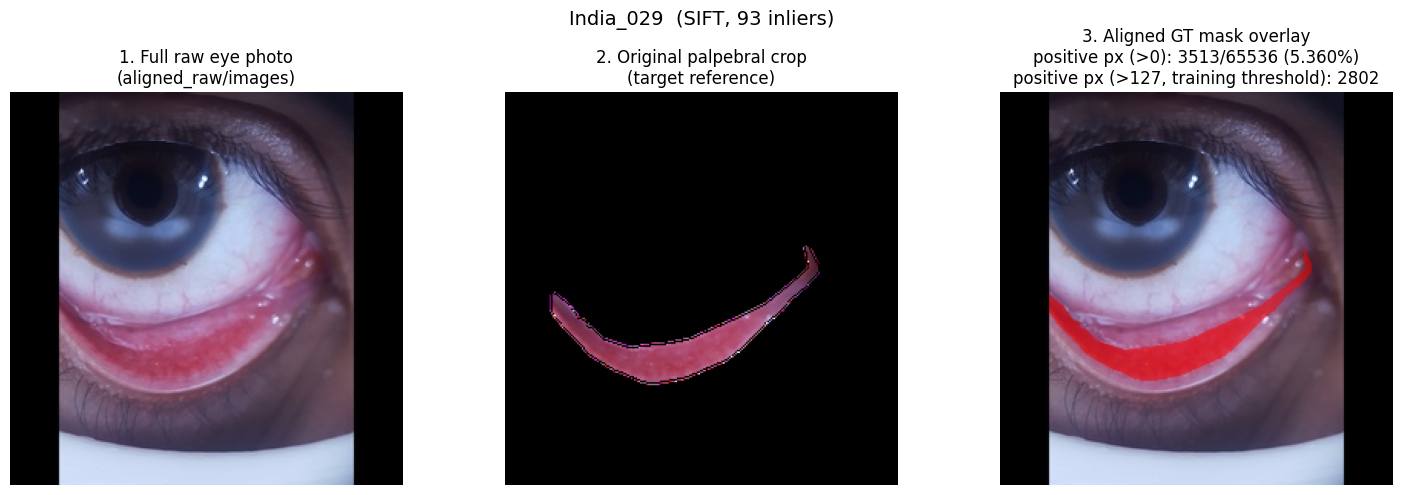

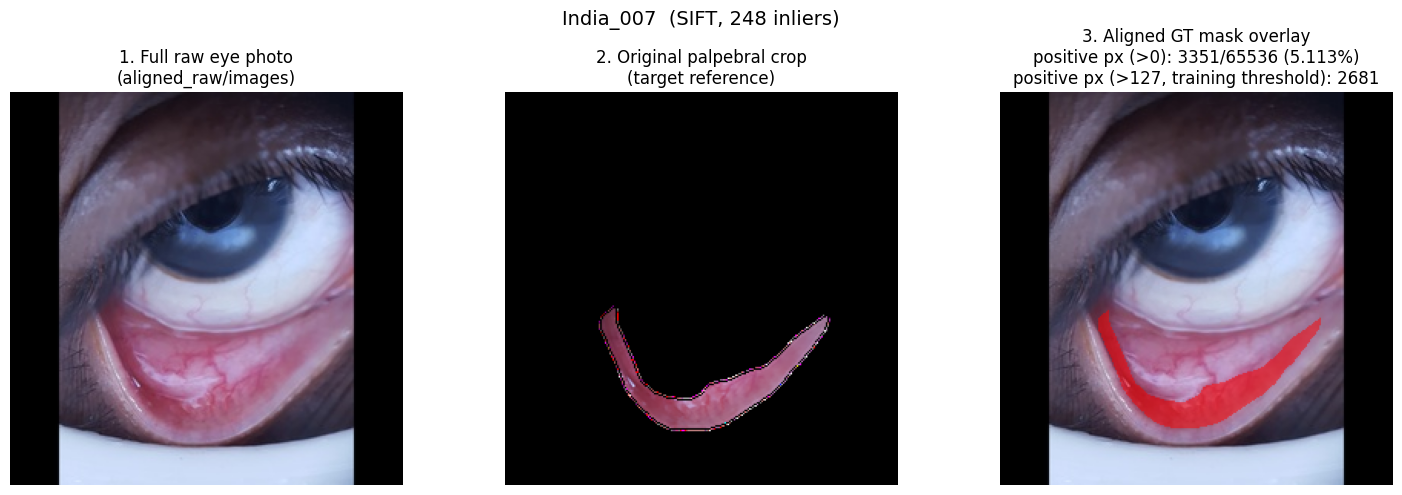

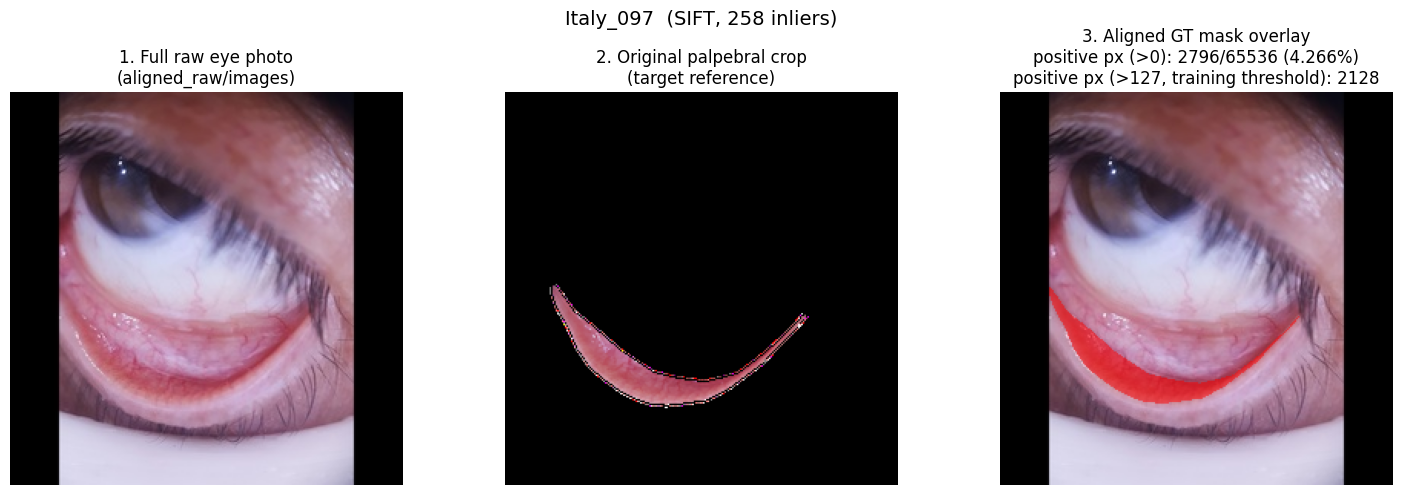

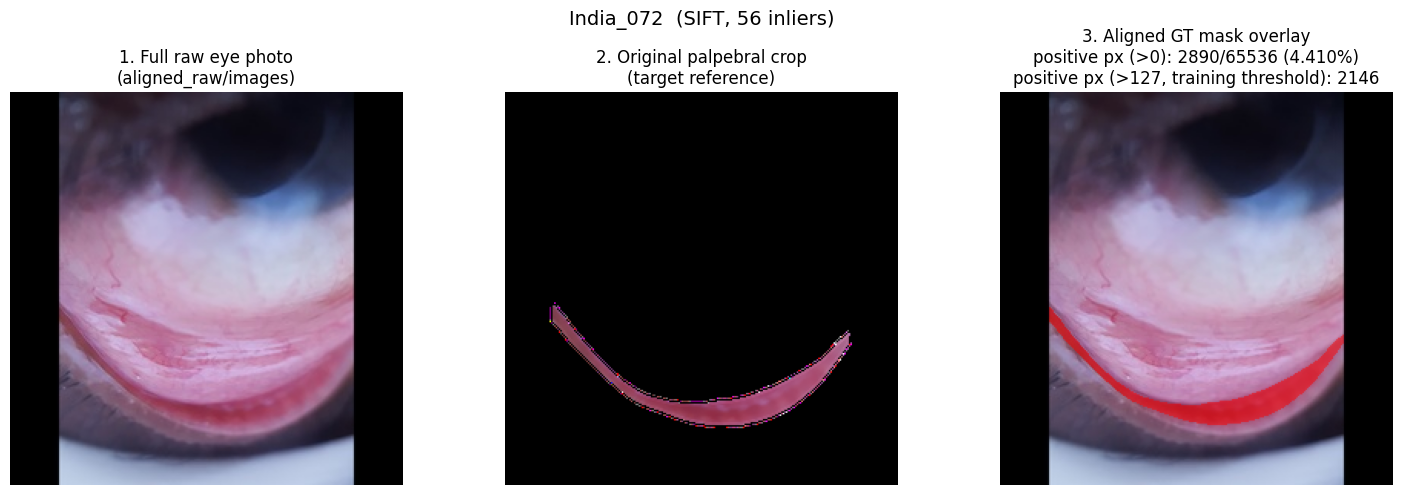

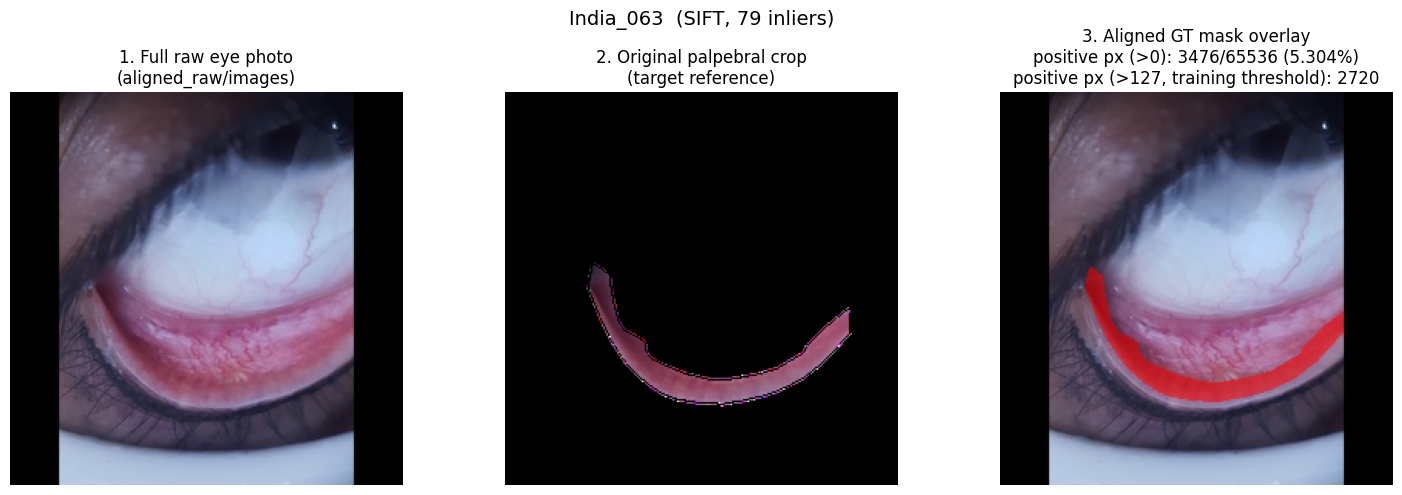

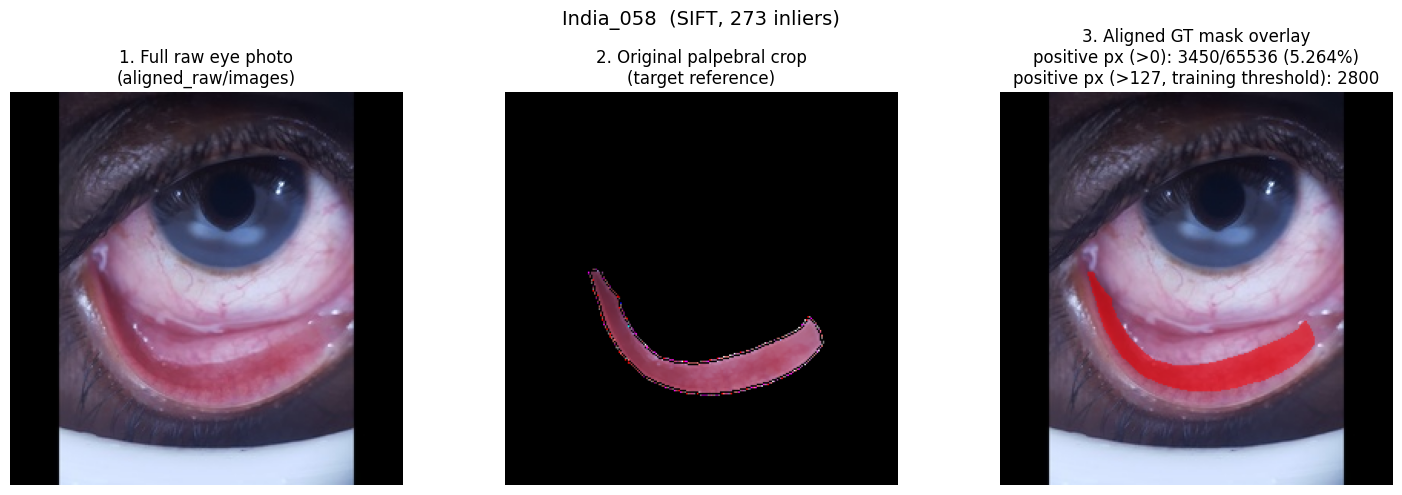

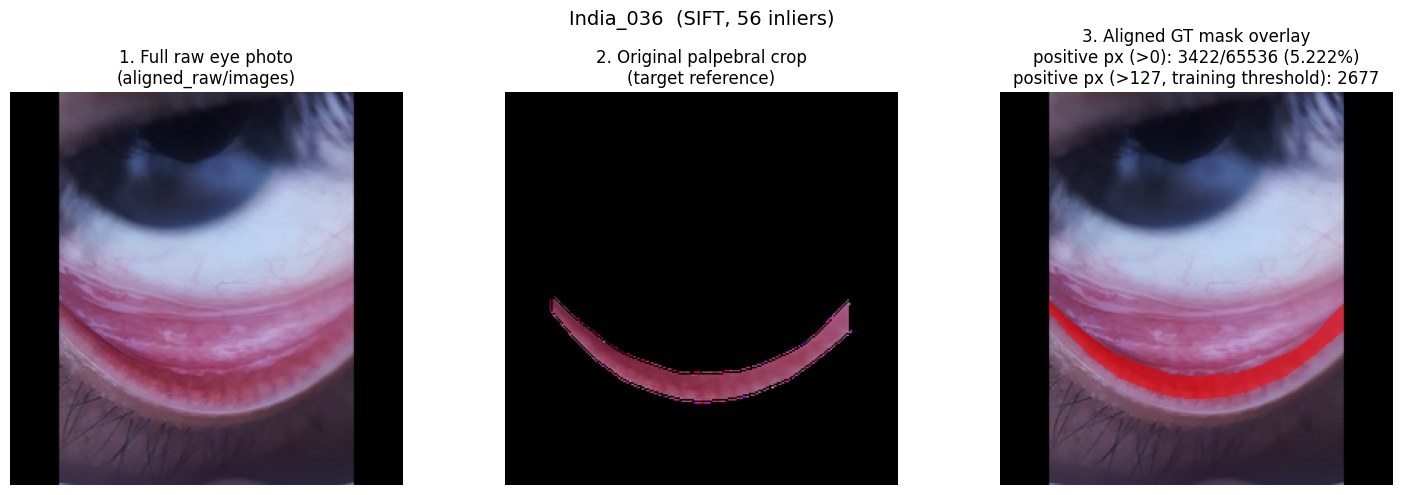

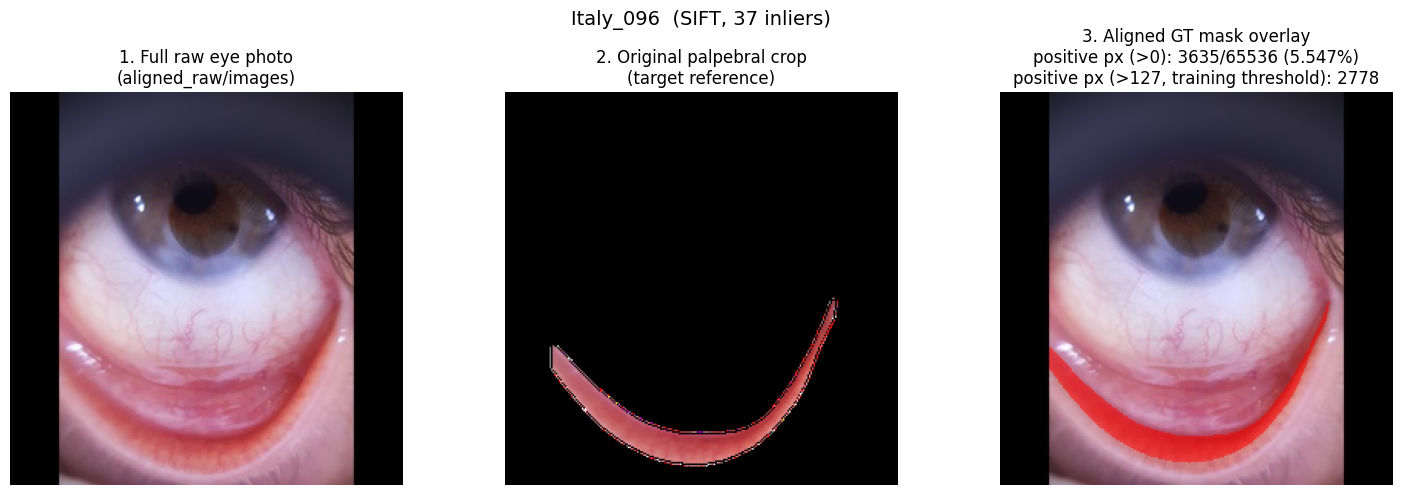

In [3]:
def load_aligned_pair(patient_id: str):
    image = np.array(Image.open(ALIGNED_IMAGES_DIR / f"{patient_id}.jpg").convert("RGB"))
    mask = np.array(Image.open(ALIGNED_MASKS_DIR / f"{patient_id}.png").convert("L"))
    return image, mask


def load_original_crop(patient_id: str):
    path = ORIGINAL_CROPS_DIR / f"{patient_id}_palpebral.png"
    return np.array(Image.open(path).convert("RGB"))


def make_overlay(image: np.ndarray, mask: np.ndarray, alpha: float = 0.5) -> np.ndarray:
    mask_bin = (mask > 127).astype(np.float32)
    red = np.zeros_like(image, dtype=np.float32)
    red[..., 0] = 255
    blended = image.astype(np.float32) * (1 - alpha * mask_bin[..., None]) + red * (alpha * mask_bin[..., None])
    return blended.astype(np.uint8)


for patient_id in sample_patient_ids:
    log_row = alignment_log.loc[patient_id] if patient_id in alignment_log.index else None
    status = log_row["status"] if log_row is not None else "not in log"

    original_crop = load_original_crop(patient_id)

    if status != "ok":
        # Alignment failed outright for this patient -- no aligned_raw files
        # exist. Show the failure explicitly rather than crashing on a
        # missing file, since "did it fail silently or loudly" matters here.
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        fig.suptitle(f"{patient_id}   ***  ALIGNMENT FAILED  ***\n{status}", fontsize=13, color="red")
        axes[0].imshow(original_crop)
        axes[0].set_title("Original palpebral crop\n(target reference)")
        axes[0].axis("off")
        axes[1].axis("off")
        axes[1].text(0.5, 0.5, "No aligned_raw output\n(alignment rejected by\ngeometric sanity check)",
                     ha="center", va="center", fontsize=12, color="red")
        plt.tight_layout()
        plt.show()
        continue

    aligned_image, aligned_mask = load_aligned_pair(patient_id)
    overlay = make_overlay(aligned_image, aligned_mask)

    # Crucial check: literal "any nonzero pixel at all" count, not the >127
    # binarization threshold -- this is the one that tells us if the mask
    # is 100% black, regardless of what threshold training actually uses.
    n_positive_strict = int((aligned_mask > 0).sum())
    n_positive_binarized = int((aligned_mask > 127).sum())  # threshold AlignedConjunctivaSegmentationDataset actually uses
    total_pixels = aligned_mask.size
    is_blank = n_positive_strict == 0

    method = log_row["method"]
    n_inliers = int(log_row["n_inliers"])

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(
        f"{patient_id}  ({method}, {n_inliers} inliers)" + ("   ***  MASK IS 100% BLACK  ***" if is_blank else ""),
        fontsize=14,
        color=("red" if is_blank else "black"),
    )

    axes[0].imshow(aligned_image)
    axes[0].set_title("1. Full raw eye photo\n(aligned_raw/images)")
    axes[0].axis("off")

    axes[1].imshow(original_crop)
    axes[1].set_title("2. Original palpebral crop\n(target reference)")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title(
        "3. Aligned GT mask overlay\n"
        f"positive px (>0): {n_positive_strict}/{total_pixels} ({100 * n_positive_strict / total_pixels:.3f}%)\n"
        f"positive px (>127, training threshold): {n_positive_binarized}"
    )
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

## Bonus: full-dataset scan (all 217 patients, not just the 10 sampled)

10 random patients could miss a partial corruption. This scans every mask actually produced in `aligned_raw/masks/` for blank/near-blank cases, and separately lists every patient whose alignment failed outright (per `alignment_log.csv`).

Alignment log status counts:
status
ok                                                               202
failed: warped crop corners fall outside the raw photo bounds     13
failed: warped area ratio 0.022 outside sanity bounds              1
failed: warped area ratio 0.000 outside sanity bounds              1
Name: count, dtype: int64

Failed patients (15/217):
patient_id
India_002    failed: warped crop corners fall outside the r...
India_003    failed: warped crop corners fall outside the r...
India_015    failed: warped crop corners fall outside the r...
India_019    failed: warped crop corners fall outside the r...
India_044    failed: warped crop corners fall outside the r...
India_050    failed: warped crop corners fall outside the r...
India_060    failed: warped area ratio 0.022 outside sanity...
India_077    failed: warped crop corners fall outside the r...
India_080    failed: warped area ratio 0.000 outside sanity...
India_082    failed: warped crop corners fall outside the

count      202.000000
mean     10318.217822
std      16628.674951
min       1793.000000
25%       2825.000000
50%       3438.000000
75%       4578.250000
max      50176.000000
Name: positive_px, dtype: float64

Fully blank masks (0 positive pixels): 0 / 202

Near-blank masks (<10 positive pixels): 0 / 202


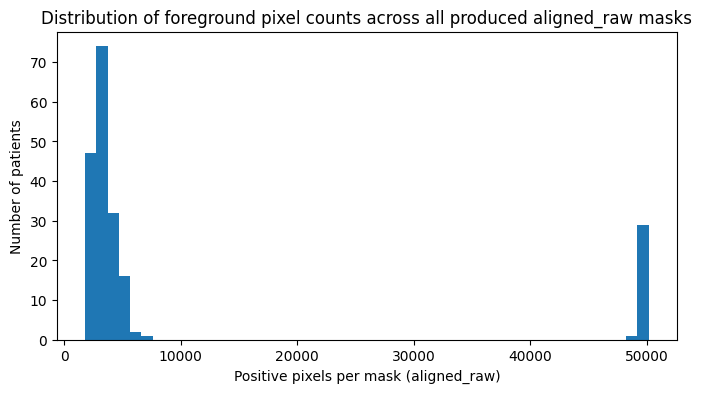

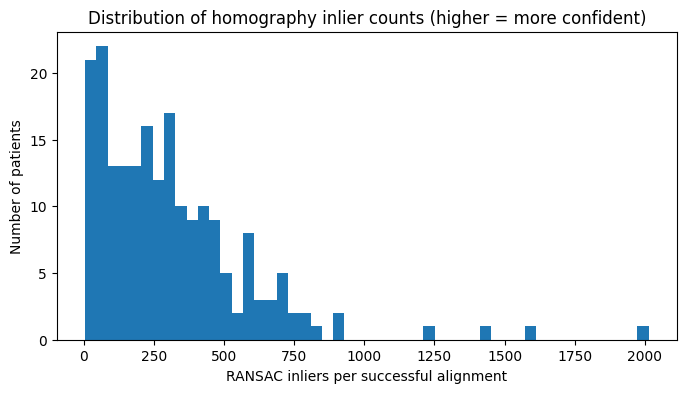

In [4]:
print(f"Alignment log status counts:\n{alignment_log['status'].value_counts()}\n")

failed = alignment_log[alignment_log["status"] != "ok"]
print(f"Failed patients ({len(failed)}/{len(alignment_log)}):")
print(failed["status"])

ok_log = alignment_log[alignment_log["status"] == "ok"]
print(f"\nMethod breakdown (successful alignments):\n{ok_log['method'].value_counts()}")
print(f"\nInlier stats: min={ok_log['n_inliers'].min()} mean={ok_log['n_inliers'].mean():.1f} max={ok_log['n_inliers'].max()}")

all_mask_paths = sorted(ALIGNED_MASKS_DIR.glob("*.png"))
print(f"\nScanning {len(all_mask_paths)} mask files actually present in {ALIGNED_MASKS_DIR} ...")

records = []
for mask_path in all_mask_paths:
    mask = np.array(Image.open(mask_path).convert("L"))
    n_positive = int((mask > 0).sum())
    records.append(
        {"patient_id": mask_path.stem, "positive_px": n_positive, "positive_frac": n_positive / mask.size}
    )

scan_df = pd.DataFrame(records)
print(scan_df["positive_px"].describe())

blank_masks = scan_df[scan_df["positive_px"] == 0]
print(f"\nFully blank masks (0 positive pixels): {len(blank_masks)} / {len(scan_df)}")
if len(blank_masks):
    print(blank_masks)

low_signal = scan_df[scan_df["positive_px"] < 10]
print(f"\nNear-blank masks (<10 positive pixels): {len(low_signal)} / {len(scan_df)}")
if len(low_signal):
    print(low_signal)

plt.figure(figsize=(8, 4))
plt.hist(scan_df["positive_px"], bins=50)
plt.xlabel("Positive pixels per mask (aligned_raw)")
plt.ylabel("Number of patients")
plt.title("Distribution of foreground pixel counts across all produced aligned_raw masks")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(ok_log["n_inliers"], bins=50)
plt.xlabel("RANSAC inliers per successful alignment")
plt.ylabel("Number of patients")
plt.title("Distribution of homography inlier counts (higher = more confident)")
plt.show()